# PM4Py 过程挖掘演示 — EvoAgent 任务流水线

**语料构成（诚实标注，铁律 1）**：`cases/` 五份 XES = **1 份真实流水线运行**（`task_real_harness.xes`：TaskStore + ReviewHarness(LocalRuleReviewer) 离线跑通，无 LLM、无网络）+ **4 份合成演示轨迹**（`task_variant_01..04`：同一导出代码路径生成，覆盖失败终态 / 重试成功 / 取消 / 代理故障恢复分支）。**合成轨迹不得对外说成真实运行。**

**依赖**：`pip install pm4py`（本演示用 pm4py 2.7.23.6）+ 系统 Graphviz `dot` 在 PATH。

**一键重建**：`python make_demo_assets.py`（生成 cases/）→ `python mine_dfg.py`（合并 + DFG 出图 ×2）。本 notebook 是同一条管线的交互式版本，运行时会把两张 DFG 图与 Petri 网图重新写回 `mining/`。

In [1]:
import os
import pandas as pd
import pm4py
from IPython.display import Image

CASES, MINING = "cases", "mining"
os.makedirs(MINING, exist_ok=True)

frames = {}
for name in sorted(os.listdir(CASES)):
    if name.endswith(".xes"):
        frames[name] = pm4py.read_xes(os.path.join(CASES, name))

log = pd.concat(frames.values(), ignore_index=True)
for name, df in frames.items():
    print("%-44s %3d events / %d case(s)" % (name, len(df), df["case:concept:name"].nunique()))
print("merged: %d cases / %d events" % (log["case:concept:name"].nunique(), len(log)))



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




/home/alkaid/miniconda3/envs/solver/lib/python3.10/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/home/alkaid/miniconda3/envs/solver/lib/python3.10/site-packages/pm4py/util/dt_parsing/parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/1 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1 [00:00<?, ?it/s]

task_real_harness.xes                          4 events / 1 case(s)
task_variant_01_failed.xes                     2 events / 1 case(s)
task_variant_02_retry_success.xes              7 events / 1 case(s)
task_variant_03_cancelled.xes                  4 events / 1 case(s)
task_variant_04_agent_failure_recovered.xes    6 events / 1 case(s)
merged: 5 cases / 23 events


In [2]:
print("activities:", sorted(log["concept:name"].unique()))
dfg, start_acts, end_acts = pm4py.discover_dfg(log)
print("start:", dict(start_acts))
print("end:  ", dict(end_acts))

activities: ['agent.agent_failure', 'agent.reproduction', 'harness.cancelled', 'harness.executing', 'harness.failed', 'harness.planning', 'harness.reviewing', 'harness.success']
start: {'harness.planning': 5}
end:   {'harness.success': 3, 'harness.failed': 1, 'harness.cancelled': 1}


In [3]:
traces = (log.sort_values("time:timestamp")
             .groupby("case:concept:name")["concept:name"]
             .apply(tuple))
for case_id, trace in traces.items():
    print("%-44s %s" % (case_id, " -> ".join(trace)))

oe1-demo-real                                harness.planning -> harness.executing -> harness.reviewing -> harness.success
task_variant_01_failed                       harness.planning -> harness.failed
task_variant_02_retry_success                harness.planning -> harness.executing -> harness.failed -> agent.agent_failure -> harness.executing -> harness.reviewing -> harness.success
task_variant_03_cancelled                    harness.planning -> harness.executing -> harness.reviewing -> harness.cancelled
task_variant_04_agent_failure_recovered      harness.planning -> harness.executing -> agent.agent_failure -> agent.reproduction -> harness.reviewing -> harness.success


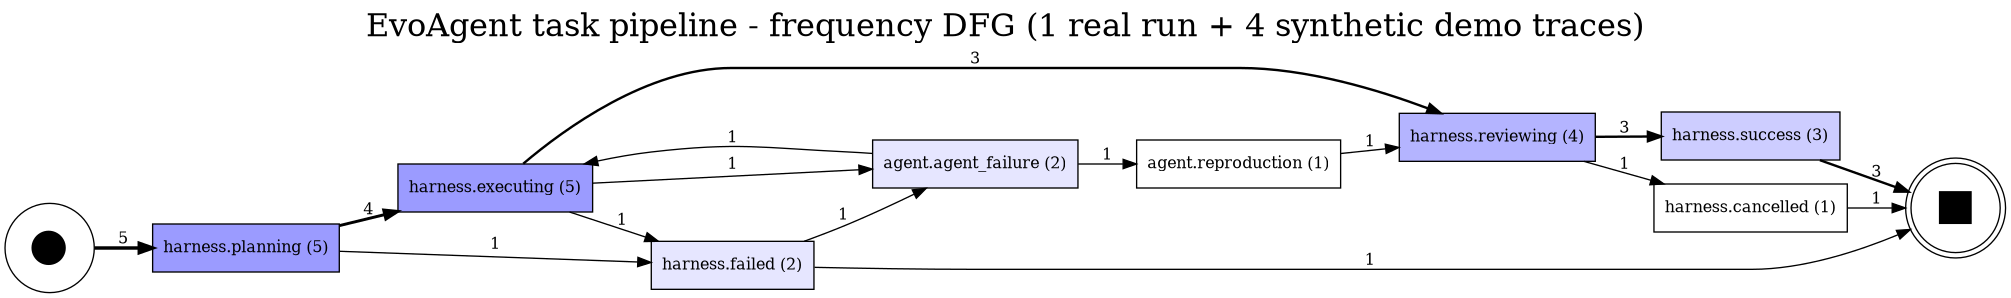

In [4]:
freq_path = os.path.join(MINING, "dfg_frequency.png")
pm4py.save_vis_dfg(dfg, start_acts, end_acts, freq_path,
    graph_title="EvoAgent task pipeline - frequency DFG "
                "(1 real run + 4 synthetic demo traces)")
Image(freq_path)

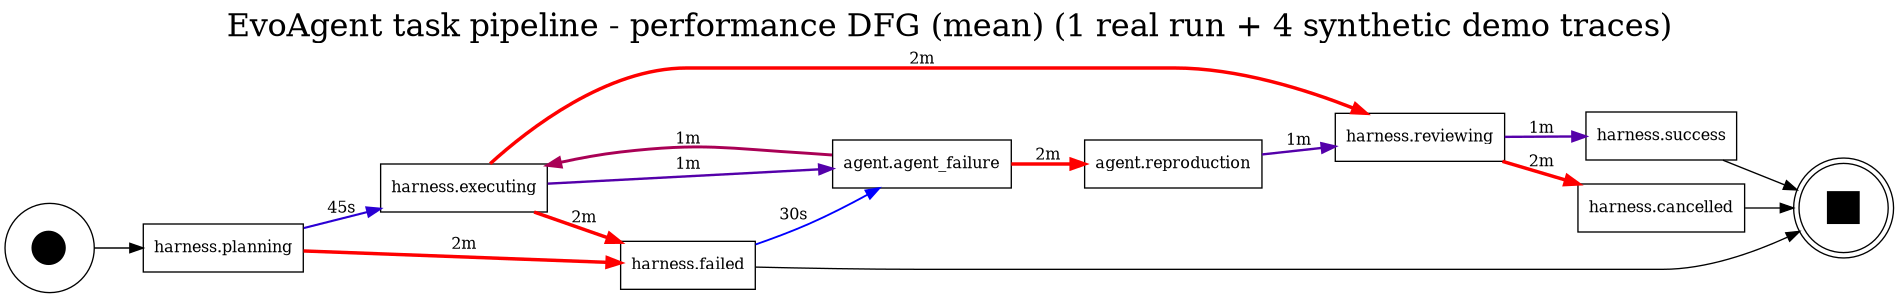

In [5]:
pdfg, psa, pea = pm4py.discover_performance_dfg(log)
perf_path = os.path.join(MINING, "dfg_performance.png")
pm4py.save_vis_performance_dfg(pdfg, psa, pea, perf_path,
    graph_title="EvoAgent task pipeline - performance DFG (mean) "
                "(1 real run + 4 synthetic demo traces)")
Image(perf_path)

places=13 transitions=17 arcs=38


replaying log with TBR, completed traces ::   0%|          | 0/5 [00:00<?, ?it/s]

token-based replay fitness: {'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}


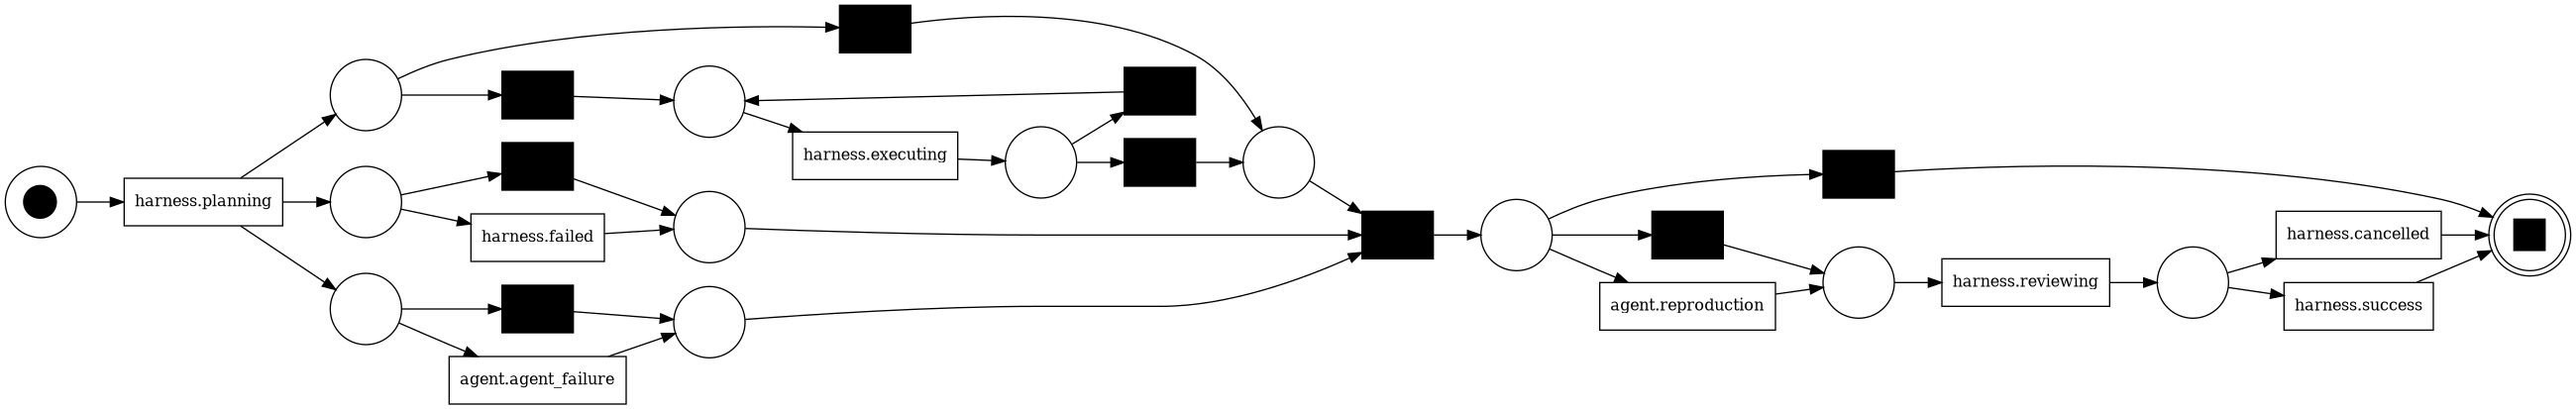

In [6]:
net, im, fm = pm4py.discover_petri_net_inductive(log)
net_path = os.path.join(MINING, "petri_net_inductive.png")
pm4py.save_vis_petri_net(net, im, fm, net_path)
print("places=%d transitions=%d arcs=%d" % (len(net.places), len(net.transitions), len(net.arcs)))
print("token-based replay fitness:", pm4py.fitness_token_based_replay(log, net, im, fm))
Image(net_path)

## 口径与复现

- 全部图基于合并语料 = **1 真实 + 4 合成**；对外引用必须保留此标注。
- Petri 网由归纳挖掘器（Inductive Miner）得到；5 条短轨迹上重放拟合度平凡为满分，仅作管线演示，不构成质量论断（铁律 2：不过度承诺）。
- 一键重建：`make_demo_assets.py` → `mine_dfg.py`；本 notebook 可独立重跑（依赖 pm4py + Graphviz dot）。